In [1]:
%pip install matplotlib numpy pandas scikit-learn 

Note: you may need to restart the kernel to use updated packages.


## Conceitos de Classificação

Dados: Dataset MNIST-784, que contem 70000 imagens preto em brancas de tamanho 28x28, ou seja, flated temos 784 features (pixeis que variam de 0 a 255), já vem preprocessado e separado.

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
X, y = mnist.data,mnist.target

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

(70000, 784)
(70000,)


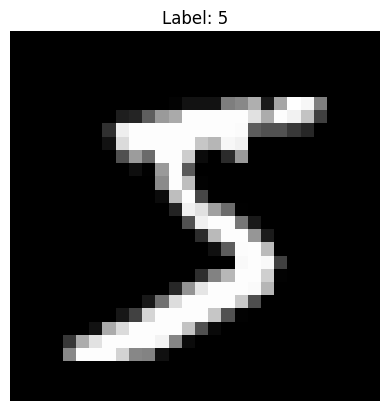

In [4]:
from matplotlib import pyplot as plt

plt.imshow(X[0].reshape(28, 28), cmap='gray') 
# reshape para transformar o vetor de 784 pixels em uma imagem 28x28, e cmap='gray' para exibir a imagem em escala de cinza.

plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

### Classificação Binária

Podemos por simplicidade treinar um modelo de classificação binária em queremos classificar se o digito é 7 ou não é 7... teremos apenas essas 2 opções. 

In [5]:
y_train_7 =  (y_train == '7')
y_test_7 =  (y_test == '7') # geramos vetores target booleanos 

from sklearn.linear_model import SGDClassifier

sgdclass_model = SGDClassifier(random_state=42) # muito util para grandes datasets, pois processa os dados em mini-batches, 
#o que reduz o uso de memória e pode acelerar o treinamento. Além disso, util em treino online pois pode ser atualizado com 
# novos dados sem precisar ser re-treinado do zero.
# Stocastic -> atualiza os pesos do modelo para cada amostra de treinamento
# Batch -> atualiza os pesos do modelo apenas após processar todo o conjunto de treinamento
# Mini-batch -> atualiza os pesos do modelo após processar um pequeno lote de amostras de treinamento (mini-batch)

sgdclass_model.fit(X_train, y_train_7)

print(sgdclass_model.predict(X[10:30]))
print(y[10:30])


[False False False False False  True False False False False False False
 False False False False False False False  True]
['3' '5' '3' '6' '1' '7' '2' '8' '6' '9' '4' '0' '9' '1' '1' '2' '4' '3'
 '2' '7']


#### Métricas de performace:

- Acurácia: Representa o quanto acertamos as classes em relacao ao total... se acertamos 9 de um total de 10 temos acuracia 9/10=0.9... O problema da acurácia é que ela pode ser facilmente enganada pela distribuicao das classes... Imagine que apenas 10% dos dados é da classe positiva. Se um modelo simples que apenas retorna falso for usado ele vai ter acurácia de 90% que pode ser mal interpretado como um modelo otimo.

In [6]:

from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier 
# DummyClassifier é um modelo de classificação que faz previsões aleatórias ou baseadas em uma estratégia simples, como a classe mais frequente. 
# ele é usado como um modelo de referência (baseline) para comparar o desempenho de outros modelos de classificação.

acuracia = cross_val_score(sgdclass_model, X_train, y_train_7, cv=3, scoring='accuracy')
print(acuracia.mean())

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train_7)
dummy_acuracia = cross_val_score(dummy_clf, X_train, y_train_7, cv=3, scoring='accuracy')
print(dummy_acuracia.mean())

# a acuracia do modelo Dummy é de quase 90%, enquanto do outro é 97%.
# significa que o modelo nao é tao bom quanto parece, pois ele tem um desempenho muito proximo do modelo Dummy, que é um modelo de referencia.


0.9708333333333333
0.8955833333333333


- Matriz de Confusao: Uma outra maneira de visualizar isso é usando uma matriz de confusao que cria uma matriz em que as linhas sao as classes reais e as colunas a classe que foi predita. Nas celulas fica a frequencia de numero de vezes que uma classe foi prevista como A mas na verdade era B. Supondo que nossa classe positiva é a classe "é sete", nossa classe negativa se torna o "nao é 7". Se previmos que é 7 e realmente é 7 entao temos um verdadeiro positivo, se previmos que é 7 mas nao é 7, entao temos um falso positivo. Se previmos que nao é 7 e de fato nao é 7, temos um verdadeiro negativo, se previmos que nao é 7 e é 7 entao temos um falso negativo... dependendo da situacao é mais interesante priorizar uma dessas classes... em exames médicos por exemplo um falso negativo pode custar vidas.

[[52389  1346]
 [  404  5861]]


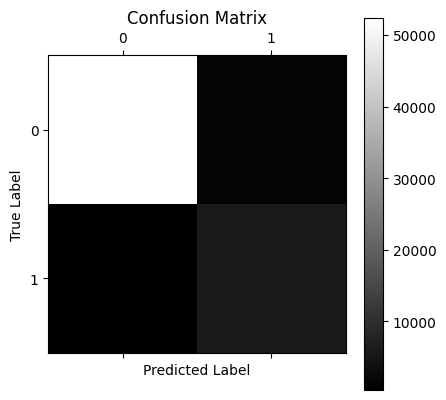

In [7]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
from matplotlib import pyplot as plt

y_train_7_pred = cross_val_predict(sgdclass_model, X_train, y_train_7, cv=3)
conf_matrix = confusion_matrix(y_train_7, y_train_7_pred) # retorna na ordem classe negativa (False) e classe positiva (True)

print(conf_matrix)

plt.matshow(conf_matrix, cmap=plt.cm.gray)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

# Como o retoro é na ordem classe negativa (False) e classe positiva (True), a matriz de confusão é interpretada da seguinte forma:
# [0,0] -> True Negatives (TN): número de vezes que o modelo previu corretamente a classe negativa (False). (52389)
# [0,1] -> False Positives (FP): número de vezes que o modelo previu incorretamente a classe positiva (True) quando a classe real era negativa (False). (1346)
# [1,0] -> False Negatives (FN): número de vezes que o modelo previu incorretamente a classe negativa (False) quando a classe real era positiva (True). (404)
# [1,1] -> True Positives (TP): número de vezes que o modelo previu corretamente a classe positiva (True). (5861)

- Precisao: Aqui estamos medindo quantas das previsoes na classe A de todas as previsoes na classe A voce acertou... por exemplo a precisao da classe positiva (7) é o quanto eu previ corretamente 7, ou seja, TP dividido pelo total que eu previ ser positivo, ou seja, TP + FP... -> P = TP/ (TP + FP). 

- Recall: Aqui queremos saber o quanto acertamos na classe A em relacao a quantos eram realmente daquela classe... por exemplo o recall da classe positiva é o quanto eu previ corretamente da classe 7, ou seja, TP dividido pelo total que existia naquela classe, ou seja, TP + FN (quantos positivos acertamos mais quantos positivos erramos) -> R =  TP/ (TP + FN). 

OBS: Ambas as métricas podem ser expandidas para N classes e nao apenas 2.

In [8]:
TP =  conf_matrix[1,1]
TN = conf_matrix[0,0]
FP = conf_matrix[0,1]
FN = conf_matrix[1,0]

precision = TP / (TP + FP) # foco em reduzir os falsos positivos, ou seja, quando o modelo prevê a classe positiva (True), ele está correto.
recall = TP / (TP + FN) # foco em reduzir os falsos negativos, ou seja, quando a classe real é positiva (True), o modelo prevê corretamente.

print(f"Precision: {precision}")
print(f"Recall: {recall}")

# O resultado da precisão é de aproximadamente 0.813, o que significa que quando o modelo prevê a classe positiva (True), ele está correto cerca de 81.3% das vezes.
# O resultado do recall é de aproximadamente 0.935, o que significa que o modelo é capaz de identificar corretamente cerca de 93.5% dos casos positivos (True) no conjunto de dados.

from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_7, y_train_7_pred)
recall = recall_score(y_train_7, y_train_7_pred)

print(f"Precision - Sklearn: {precision}")
print(f"Recall - Sklearn: {recall}")


Precision: 0.8132371305675038
Recall: 0.9355147645650439
Precision - Sklearn: 0.8132371305675038
Recall - Sklearn: 0.9355147645650439


F1: É conveniente transformar o recall e precision em apenas um numero... isso é feito usando média harmonica: Enquanto a média aritmética é generosa e tenta equilibrar os valores, a harmônica não passa pano para valores baixos. Um dos valores da média harmonica é baixo (recall ou precision) o valor da media é puxado drasticamente para baixo e isso torna o F1 perfeito pois ele só será alto se ambos recall ou precision forem altos pois se um deles for por baixo o valor do F1 sera baixo.

$$
H = \frac{n}{\sum_{i=1}^{n} \frac{1}{x_i}}
$$

F1 é interessante para casos em que queremos que o recall e precision tenham valores proximos e altos mas isso nem sempre é verdade. Quanto maior a precisao menos os falsos positivos... em uma situacao em que queremos classficar se um conteudo é ou nao seguro para criancas vamos querem aumentar o máximo possivel a precisao pois nao queremos que conteudos sensiveis cheguem as criancas através de falsos positivos (predito seguro mas nao era) mas se o recall for baixo nao tem problema pois iremos filtrar conteudos seguros (falsos negativos) e isso nao é tao grave... Quanto maior o recall menor o numero de falsos negativos... em uma situacao em que queremos classificar se uma pessoa tem cancer é mais interessante ter um recall muito alto para evitar casos em que dizemos que ele nao tem cancer e na verdade ele tem e acabar causando a morte dele... falsos positivos podem causar problemas mas nao a morte de alguém pelo menos entao precision nao é tao vital.

In [9]:
F1 = 2 / (1/precision + 1/recall) 

print(f"F1 Score: {F1}")

from sklearn.metrics import f1_score

f1 = f1_score(y_train_7, y_train_7_pred)
print(f"F1 Score - Sklearn: {f1}")

F1 Score: 0.8701009501187649
F1 Score - Sklearn: 0.8701009501187649


O tradeoff entre recall e precisao:

Em classificao binário temos um conceitos que é chamado de threshold que funciona como um valor minimo de tomada de decisao... na classificacao binária a saida é a probabilidade da classe positiva (probabilidade de ser 7), o threshold é o limite em que consideramos a instacia/ponto como positivo ou negativo. Se a probabilidade é 0.8 e o threshold é 0.5 entao é classe positiva mas se o threshold é 0.95 entao é classe negativa. A alteracao desse limiar nos permite controlar o tradeoff de recall e precisao em que quanto maior o threshold mais vamos reduzir a incerteza do positivo (fica mais dificil ser da classe positiva) e consequentemente os falsos positivos vao ser reduzidos assim aumentando a precisao... se reduzirmos o threshold teremos maior facilidade e menor garantia em ralacao a classe positiva e consequentemente teremos menos falsos negativos e maior recall. Esse threshold existe dessa maneira apenas na classificacao binária mas pode existir na multiclasse como uma especie de confianca minima para aceitar a predicao (se a classe com maior p tem p < 0.8 entao colocamos como incerto)...

O Recall só cai quando você aumenta o limiar (é monotônico). Já a Precisão pode cair um pouco antes de subir de novo se, ao mover o limiar para a direita, você descartar um "Verdadeiro Positivo" antes de descartar um "Falsos Positivo". Além disso, existem duas formas comuns de escolher um threshold:
- Grafico precisao e recall x threshold: Colocamos a curva de recall e precisao em relacao a varios threshold para escolher um ponto em que melhor beneficie meu projeto (queremos recall 80% por exemplo).
- Grafico precisao x recall: colocamos um em um eixo e o outro no outro e visualizamos os pontos que estao antes das quedas.

Além disso, no scikit temos classes:

- FixedThresholdClassifier: Um "embrulho" (wrapper) onde você define o limiar manualmente e ele cuida do resto.
- TunedThresholdClassifierCV: O modo "piloto automático". Ele testa vários limiares via validação cruzada para encontrar o que maximiza uma métrica que você escolher.

No fim é muito facil ter precisao muito alta pois simplesmente se queremos 100% de precisao entao é só classificar como positivo apenas os que eu tenho certeza que é da classe positiva e ai teremos zero falsos positivos e consequentemente precisao de 100%. Se a precisao é muita pergunte sobre o recall... Além disso, nunca escolher o threshold apenas em dados de treino pois isso é equivalente a overfit o interessante é usar validacao ou crossval.

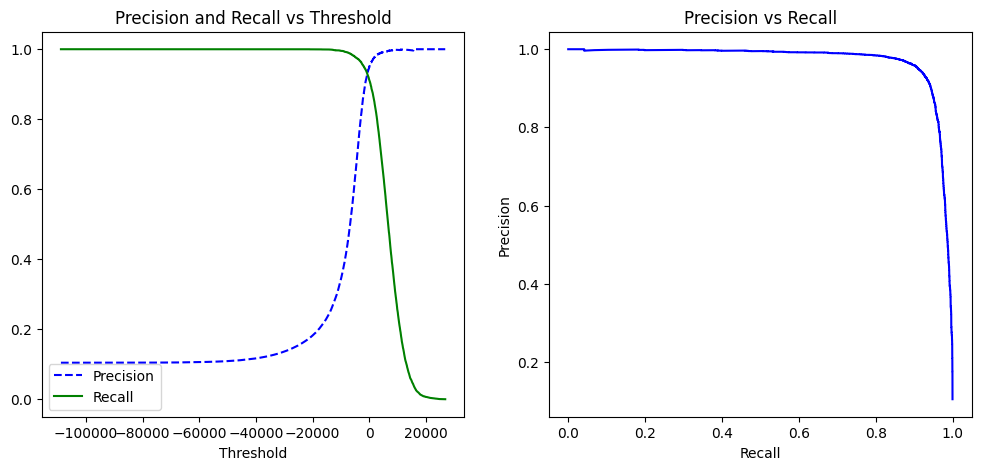

Fixed -2000 Threshold Precision: 0.8715998830067271
Fixed -2000 Threshold Recall: 0.951316839584996
Fixed 2000 Threshold Precision: 0.9783864356251164
Fixed 2000 Threshold Recall: 0.8381484437350359
Tuned Threshold Precision: 0.9771723122238586
Tuned Threshold Recall: 0.8472466081404629


In [10]:
from sklearn.metrics import precision_recall_curve

y_scores = sgdclass_model.decision_function(X_train) # [-inf, +inf]
# retorna o score de decisão para cada amostra, que é a distância da amostra ao hiperplano de decisão. 
# O threshold padrao é 0.
# Quanto maior o score, mais confiante o modelo está de que a amostra pertence à classe positiva (True).
precisions, recalls, thresholds = precision_recall_curve(y_train_7, y_scores)


_, axes = subplots = plt.subplots(1, 2, figsize=(12, 5))

# Precision x threshold e Recall x threshold são gráficos que mostram como a precisão e o recall variam em função do valor do threshold.
axes[0].plot(thresholds, precisions[:-1], "b--", label="Precision")
axes[0].plot(thresholds, recalls[:-1], "g-", label="Recall")
axes[0].set_xlabel("Threshold")
axes[0].set_title("Precision and Recall vs Threshold")
axes[0].legend()

# Precision x recall curve é um gráfico que mostra a relação entre a precisão e o recall para diferentes valores de threshold.
axes[1].plot(recalls, precisions, "b-")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision vs Recall")
plt.show()

from sklearn.model_selection import FixedThresholdClassifier, TunedThresholdClassifierCV

# fixed -2000 threshold
fixed_threshold_clf = FixedThresholdClassifier(estimator=sgdclass_model, threshold=-2000)
fixed_threshold_clf.fit(X_train, y_train_7)
y_fixed_threshold_pred = fixed_threshold_clf.predict(X_train)
fixed_threshold_precision = precision_score(y_train_7, y_fixed_threshold_pred)
fixed_threshold_recall = recall_score(y_train_7, y_fixed_threshold_pred)

print(f"Fixed -2000 Threshold Precision: {fixed_threshold_precision}")
print(f"Fixed -2000 Threshold Recall: {fixed_threshold_recall}")

# fixed 2000 threshold
fixed_threshold_clf = FixedThresholdClassifier(estimator=sgdclass_model, threshold=2000)
fixed_threshold_clf.fit(X_train, y_train_7)
y_fixed_threshold_pred = fixed_threshold_clf.predict(X_train)
fixed_threshold_precision = precision_score(y_train_7, y_fixed_threshold_pred)
fixed_threshold_recall = recall_score(y_train_7, y_fixed_threshold_pred)
print(f"Fixed 2000 Threshold Precision: {fixed_threshold_precision}")
print(f"Fixed 2000 Threshold Recall: {fixed_threshold_recall}")

tuned_threshold_clf = TunedThresholdClassifierCV(estimator=sgdclass_model, cv=3, scoring='f1')
tuned_threshold_clf.fit(X_train, y_train_7)
y_tuned_threshold_pred = tuned_threshold_clf.predict(X_train)
tuned_threshold_precision = precision_score(y_train_7, y_tuned_threshold_pred)
tuned_threshold_recall = recall_score(y_train_7, y_tuned_threshold_pred)

print(f"Tuned Threshold Precision: {tuned_threshold_precision}")
print(f"Tuned Threshold Recall: {tuned_threshold_recall}")



Curva ROC: é outra métrica usada para qualidade em que a curva é construida usando o Recall x FPR(Fake positive rate)... FPR é proxy inverso da precisao pois quanto maior a quantidade de falsos positivos menor é a precisao. Entao basicamente estamos pegando a curva Precision x Recall e invertendo o eixo... bem menos intuitivo mas ainda usam bastante essa curva para tirar uma métrica chamada AUC que é a area de baixo da curva ROC. Quanto maior o recall e a precisão, maior o AUC, pois o modelo é capaz de identificar corretamente os casos positivos (True) e evitar falsos positivos (False).


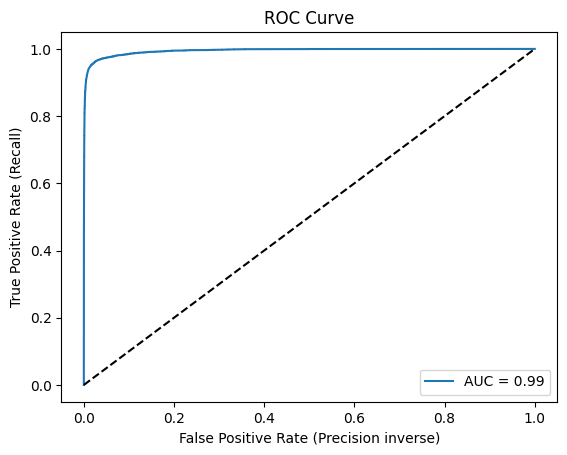

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_scores = sgdclass_model.decision_function(X_train)
fpr, tpr, thresholds = roc_curve(y_train_7, y_scores)
auc = roc_auc_score(y_train_7, y_scores) # AUC (Area Under the Curve) é uma métrica que representa a área sob a curva ROC. 
# representa a capacidade do modelo de distinguir entre as classes positiva e negativa. Quanto mais próximo de 1, melhor o desempenho do modelo.

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate (Precision inverse)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Classificacao Multiclasse